# Customer Churn Prediction for SyriaTel

# 1. BUSINESS UNDERSTANDING
## Business Problem
SyriaTel, a telecommunications company, is experiencing customer churn, which leads to revenue loss. Retaining existing customers is more cost-effective than acquiring new ones.

## Objective
The goal of this project is to build a classification model that predicts whether a customer is likely to churn. This will allow the company to proactively identify at-risk customers and implement retention strategies.

## Stakeholder
The primary stakeholders are SyriaTel’s marketing and customer retention teams, who can use model predictions to target high-risk customers with interventions.

## Success Metric
Recall will be prioritized, as failing to identify customers who churn (false negatives) results in direct revenue loss.

In [93]:
#Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [94]:
#Loading dataset
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


# 2. DATA UNDERSTANDING
This section explores the structure, quality, and basic characteristics of the dataset.

In [95]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (3333, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls     

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [96]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [97]:
# Check for missing values
print("Missing Values Per Column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values Per Column:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Total Missing Values: 0


In [98]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


###
The data understanding phase focused on exploring the dataset to gain insights into its structure, variables, and overall quality before conducting preprocessing and analysis. This stage is important for identifying potential data quality issues and understanding the characteristics of the dataset.

The telecommunications churn dataset contains customer information related to account details, service usage patterns, subscription plans, customer support interactions, and churn status. Initial exploration was conducted to understand the composition and reliability of the data.

The following activities were performed during this phase:

- Displaying the first few rows of the dataset to understand the format and structure of the data
- Examining the number of rows and columns in the dataset
- Reviewing column names and data types
- Generating descriptive statistics for numerical variables
- Checking for missing values across all features
- Checking for duplicate records within the dataset

The initial assessment revealed that the dataset contains no missing values and no duplicate records. These findings indicate that the dataset is relatively complete and consistent for further preprocessing and analysis.

The insights obtained during this phase provided the foundation for the subsequent data preparation stage, where data cleaning, transformation, and exploratory data analysis were conducted.


# 3. DATA PREPARATION

## 3.1 Data Cleaning

In [99]:
# Drop irrelevant columns
df = df.drop(columns=['phone number', 'state', 'area code'])

# Display remaining columns
df.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


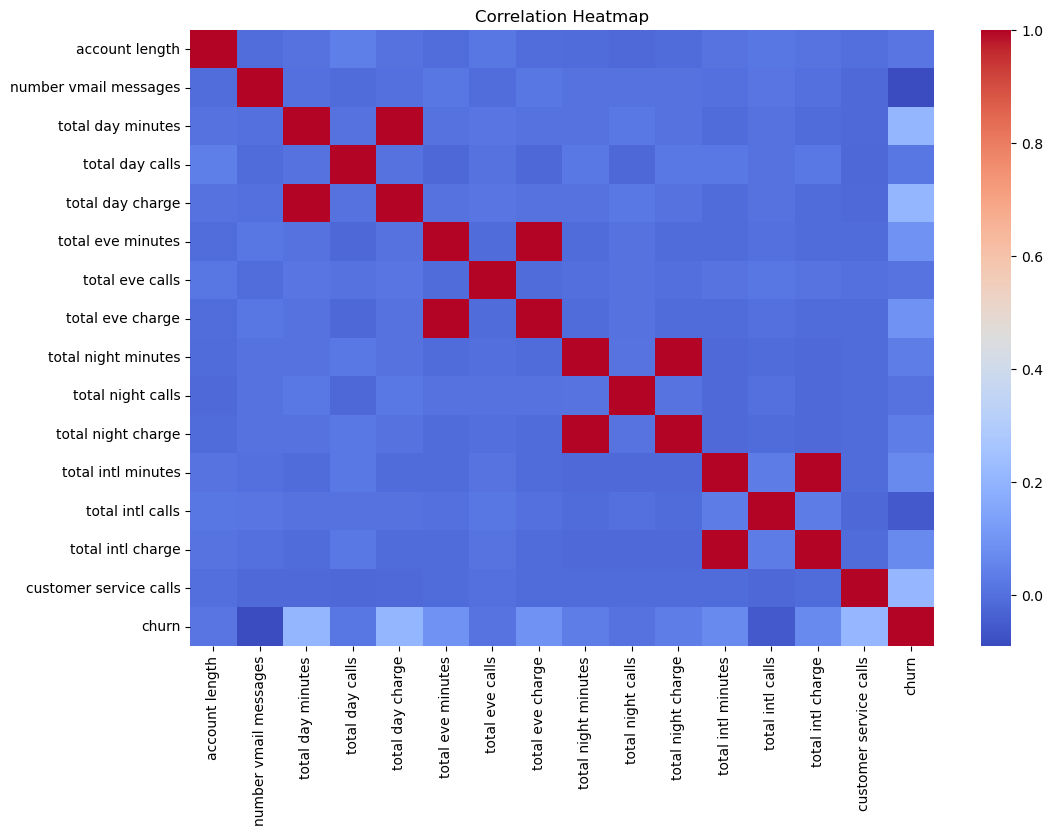

In [100]:
#checking correlation
import seaborn as sns
import matplotlib.pyplot as plt

# Plot correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

### Handling Highly Correlated Features

The correlation heatmap revealed extremely strong positive correlations between the charge-related variables and their corresponding call minutes variables. Since the charge variables are directly derived from the call duration variables, they provide redundant information and may introduce multicollinearity into the predictive models.

To reduce redundancy and improve model efficiency, the charge-related columns were removed from the dataset.

In [101]:
# Remove highly correlated charge columns
df = df.drop(columns=[
    'total day charge',
    'total eve charge',
    'total night charge',
    'total intl charge'
])

df.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,churn
0,128,no,yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,no,yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,no,no,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,yes,no,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,yes,no,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


In [102]:
print(df['churn'].unique())
print(df['international plan'].unique())
print(df['voice mail plan'].unique())

[False  True]
['no' 'yes']
['yes' 'no']


In [103]:
# Encode binary categorical variables

df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})

df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

df['churn'] = df['churn'].map({True: 1, False: 0})

In [104]:
print(df[['international plan', 'voice mail plan', 'churn']].head())

   international plan  voice mail plan  churn
0                   0                1      0
1                   0                1      0
2                   0                0      0
3                   1                0      0
4                   1                0      0


In [105]:
# Final dataset check after cleaning
print(df.info())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   international plan      3333 non-null   int64  
 2   voice mail plan         3333 non-null   int64  
 3   number vmail messages   3333 non-null   int64  
 4   total day minutes       3333 non-null   float64
 5   total day calls         3333 non-null   int64  
 6   total eve minutes       3333 non-null   float64
 7   total eve calls         3333 non-null   int64  
 8   total night minutes     3333 non-null   float64
 9   total night calls       3333 non-null   int64  
 10  total intl minutes      3333 non-null   float64
 11  total intl calls        3333 non-null   int64  
 12  customer service calls  3333 non-null   int64  
 13  churn                   3333 non-null   int64  
dtypes: float64(4), int64(10)
memory usage: 3

The dataset was cleaned and transformed to improve consistency and suitability for analysis and modeling. Irrelevant features were removed, highly correlated variables were eliminated to reduce multicollinearity, and categorical variables were encoded into numerical format. After preprocessing, the dataset was verified to ensure there were no missing values or inconsistencies before conducting exploratory data analysis.

## 3.2 Exploratory Data Analysis (EDA)

churn
0    2850
1     483
Name: count, dtype: int64


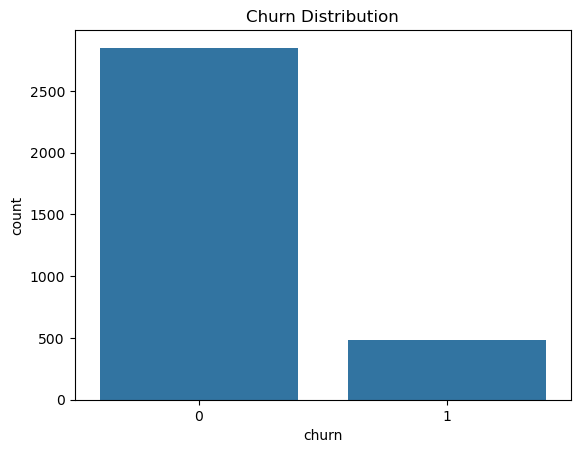

In [106]:
# Churn distribution
print(df['churn'].value_counts())

sns.countplot(x='churn', data=df)

plt.title('Churn Distribution')

plt.show()

The churn distribution indicates that the dataset is imbalanced, with non-churn customers significantly outnumbering churn customers. This imbalance will be considered during model evaluation since it may affect the performance of classification algorithms.

### Distribution of Numerical Features

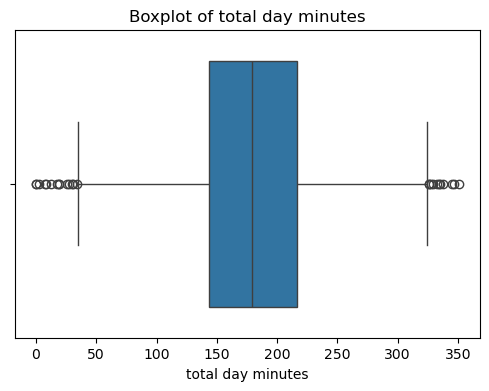

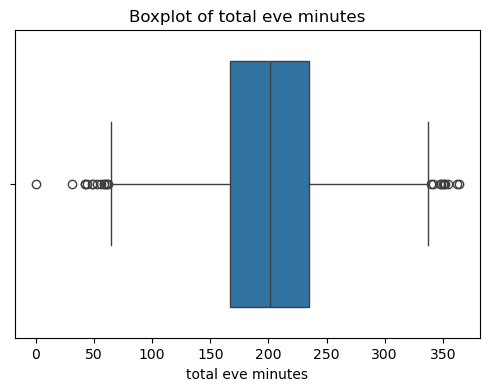

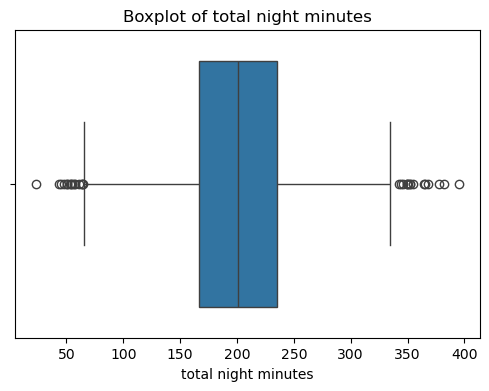

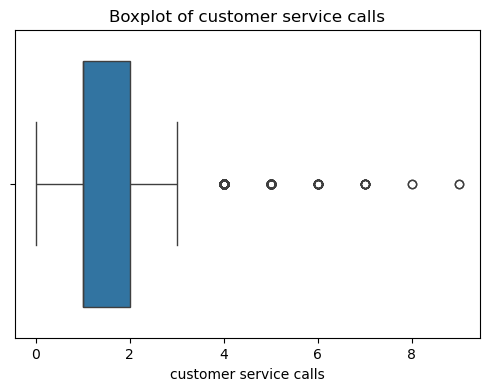

In [107]:
# Boxplots for numerical features

numerical_cols = [
    'total day minutes',
    'total eve minutes',
    'total night minutes',
    'customer service calls'
]

for col in numerical_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

The boxplots reveal the distribution and spread of key numerical variables within the dataset. Several variables contain potential outliers, particularly in customer service calls and usage-related features. These outliers may represent unusual customer behavior patterns and could provide meaningful insights during churn prediction modeling.

### International Plan and Churn

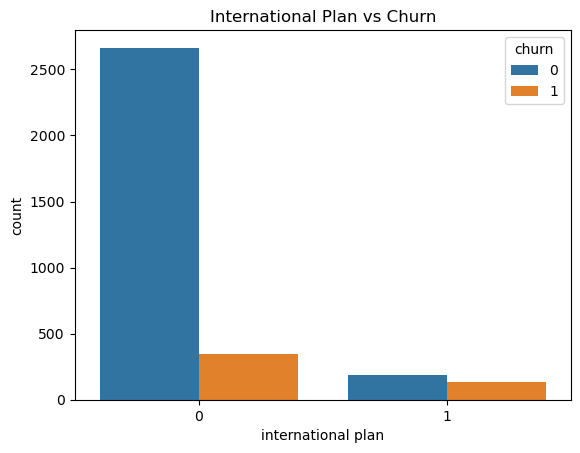

In [108]:
# International plan vs churn

sns.countplot(x='international plan', hue='churn', data=df)

plt.title('International Plan vs Churn')

plt.show()

The visualization indicates that customers subscribed to an international plan are more likely to churn compared to customers without the plan. This suggests that international plan subscription may be an important factor influencing customer retention.

### Voice Mail Plan and Churn

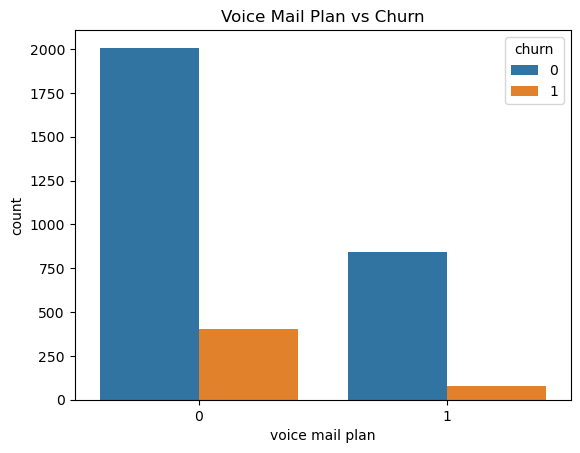

In [109]:
# Voice mail plan vs churn

sns.countplot(x='voice mail plan', hue='churn', data=df)

plt.title('Voice Mail Plan vs Churn')

plt.show()

The visualization suggests that customers without a voice mail plan are more likely to churn compared to customers subscribed to the service. This may indicate that customers using additional service features are more likely to remain with the company.

### Customer Service Calls and Churn

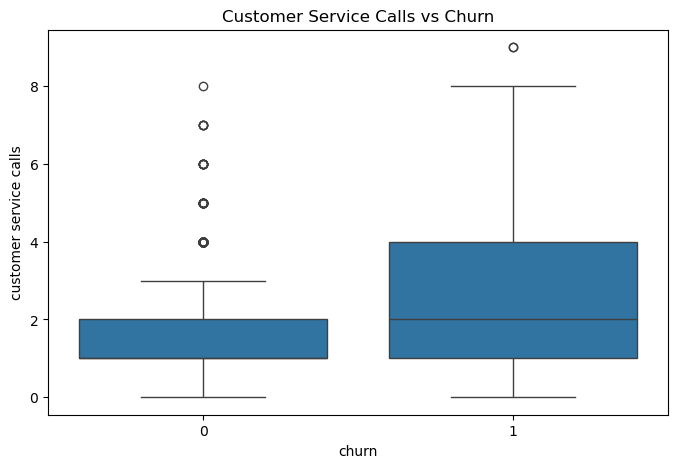

In [110]:
# Customer service calls vs churn

plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='customer service calls', data=df)

plt.title('Customer Service Calls vs Churn')

plt.show()

The boxplot shows that customers who churned generally made more customer service calls compared to non-churn customers. This suggests that frequent customer support interactions may be associated with customer dissatisfaction and increased likelihood of churn.

### Correlation Analysis

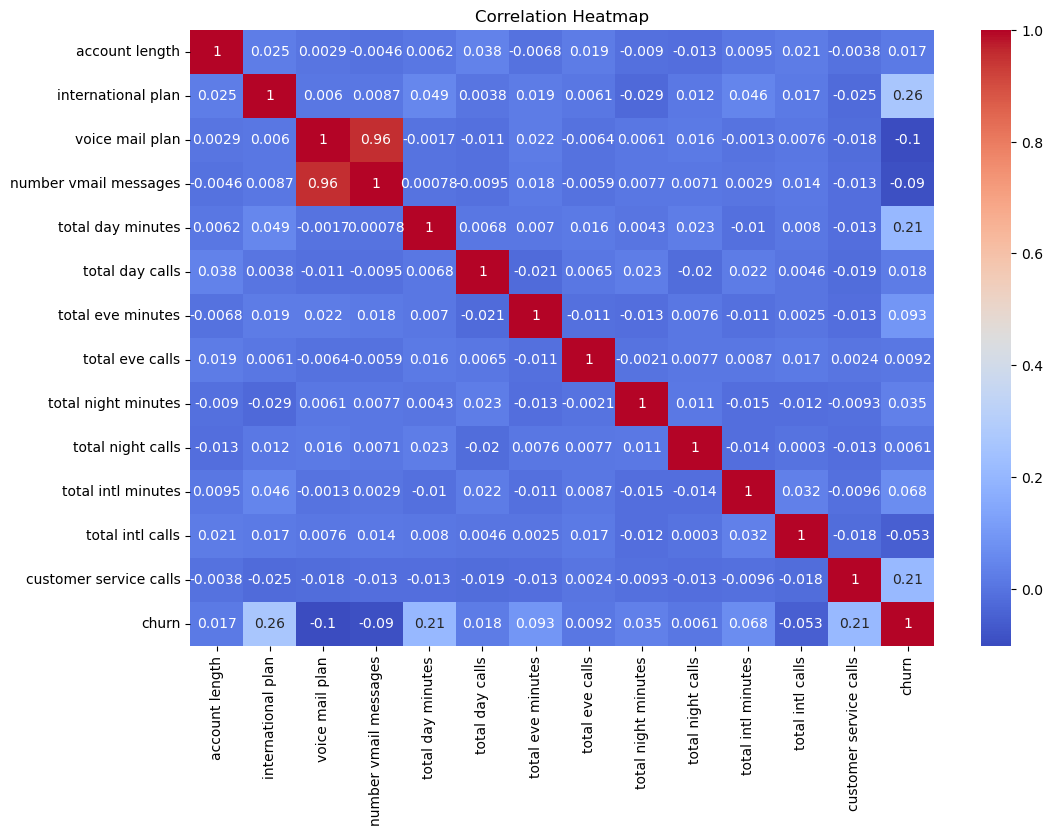

In [111]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

The correlation heatmap illustrates the relationships between variables within the dataset. International plan, total day minutes, and customer service calls show relatively stronger positive relationships with churn compared to other variables. The removal of highly correlated charge variables during data preparation helped reduce multicollinearity within the dataset.

# 4. MODELING

## 4.1 Feature Selection and Data Splitting

In [112]:
# Define features and target variable

X = df.drop('churn', axis=1)

y = df['churn']

print("Feature Matrix Shape:", X.shape)

print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (3333, 13)
Target Variable Shape: (3333,)


In [113]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (2666, 13)
Testing Features Shape: (667, 13)


### Feature Scaling

In [114]:
# Scale numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## 4.2 Logistic Regression Model

Logistic Regression was used as the baseline classification model for predicting customer churn. The model estimates the probability of a customer churning based on the selected features within the dataset.

In [115]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [116]:
# Generate predictions

y_pred_log = log_reg.predict(X_test_scaled)

 ### Logistic Regression Evaluation

In [117]:
# Evaluate Logistic Regression model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy Score:
0.8545727136431784

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.57      0.17      0.26       101

    accuracy                           0.85       667
   macro avg       0.72      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667


Confusion Matrix:
[[553  13]
 [ 84  17]]


The Logistic Regression model achieved an accuracy of approximately 85%, indicating strong overall predictive performance. However, the recall score for churn customers was relatively low, suggesting that the model struggled to correctly identify many customers who actually churned. This outcome is likely influenced by the class imbalance within the dataset, where non-churn customers significantly outnumber churn customers.

### Improved Logistic Regression Model

In [118]:
# Improved Logistic Regression with balanced class weights

log_reg_balanced = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

log_reg_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [119]:
# Generate predictions

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

In [120]:
# Evaluate improved Logistic Regression model

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy Score:
0.7841079460269865

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       566
           1       0.39      0.77      0.52       101

    accuracy                           0.78       667
   macro avg       0.67      0.78      0.69       667
weighted avg       0.87      0.78      0.81       667


Confusion Matrix:
[[445 121]
 [ 23  78]]


The improved Logistic Regression model achieved a significant increase in recall for churn customers after applying balanced class weights. While the overall accuracy decreased slightly, the model became substantially better at identifying customers likely to churn. This tradeoff is acceptable in churn prediction problems because correctly detecting potential churners is often more important than maximizing overall accuracy.

## 4.3 Decision Tree Classifier

In [121]:
# Train Decision Tree model

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [122]:
# Generate predictions

y_pred_dt = dt_model.predict(X_test)

### Decision Tree Evaluation

In [123]:
# Evaluate Decision Tree model

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy Score:
0.9370314842578711

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       566
           1       0.88      0.67      0.76       101

    accuracy                           0.94       667
   macro avg       0.91      0.83      0.86       667
weighted avg       0.93      0.94      0.93       667


Confusion Matrix:
[[557   9]
 [ 33  68]]


The Decision Tree Classifier achieved strong overall performance, with an accuracy of approximately 94%. Compared to Logistic Regression, the model demonstrated better balance between precision and recall for churn prediction. The model was able to identify churn customers more effectively while maintaining high overall classification performance, indicating that Decision Trees are better suited for capturing complex relationships within the dataset.

## 4.4 Tuned Decision Tree Model

In [124]:
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_tuned.fit(X_train, y_train)

y_pred_dt_tuned = dt_tuned.predict(X_test)

print(confusion_matrix(y_test, y_pred_dt_tuned))
print(classification_report(y_test, y_pred_dt_tuned))

[[557   9]
 [ 34  67]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       566
           1       0.88      0.66      0.76       101

    accuracy                           0.94       667
   macro avg       0.91      0.82      0.86       667
weighted avg       0.93      0.94      0.93       667



The tuned Decision Tree model achieved performance results similar to the original Decision Tree model. Although hyperparameter tuning slightly reduced model complexity, there was no substantial improvement in predictive performance. This suggests that the original Decision Tree model had already achieved near-optimal performance for the dataset.

# 5. EVALUATION

## Model Comparison

In [125]:
# model comparison table

model_results = pd.DataFrame({

    'Model': [
        'Baseline Logistic Regression',
        'Improved Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned)
    ],

    'Precision (Churn)': [
        0.57,
        0.39,
        0.88,
        0.88
    ],

    'Recall (Churn)': [
        0.17,
        0.77,
        0.67,
        0.66
    ],

    'F1-Score (Churn)': [
        0.26,
        0.52,
        0.76,
        0.76
    ]

})

model_results

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,Baseline Logistic Regression,0.854573,0.57,0.17,0.26
1,Improved Logistic Regression,0.784108,0.39,0.77,0.52
2,Decision Tree,0.937031,0.88,0.67,0.76
3,Tuned Decision Tree,0.935532,0.88,0.66,0.76


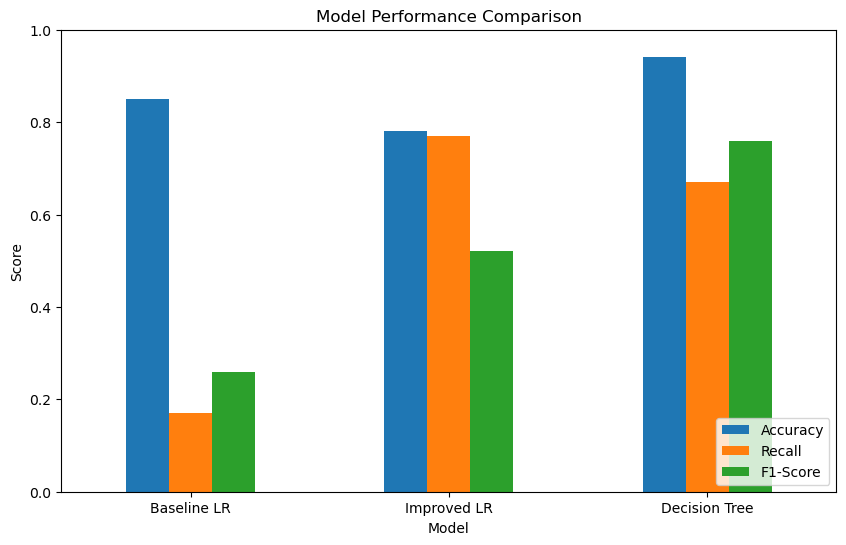

In [128]:
# Model performance comparison chart

import matplotlib.pyplot as plt
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': [
        'Baseline LR',
        'Improved LR',
        'Decision Tree'
    ],
    
    'Accuracy': [0.85, 0.78, 0.94],
    
    'Recall': [0.17, 0.77, 0.67],
    
    'F1-Score': [0.26, 0.52, 0.76]
})

comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.ylim(0,1)

plt.legend(loc='lower right')

plt.show()

The comparison results indicate that the Decision Tree models achieved the strongest overall predictive performance. Although the improved Logistic Regression model achieved the highest recall for churn detection, it produced lower precision and overall accuracy. The Decision Tree model provided the best balance between accuracy, precision, recall, and F1-score, making it the most suitable model for customer churn prediction in this project.

Based on the evaluation results, the original Decision Tree Classifier was selected as the final model for this project. The model demonstrated strong overall classification performance while maintaining a good balance between churn detection capability and prediction accuracy.

The Decision Tree model achieved:

- High overall accuracy
- Strong precision for churn prediction
- Good recall for identifying churn customers
- Balanced F1-score performance

These results indicate that the model is effective for identifying customers likely to churn while minimizing incorrect predictions.

<Axes: >

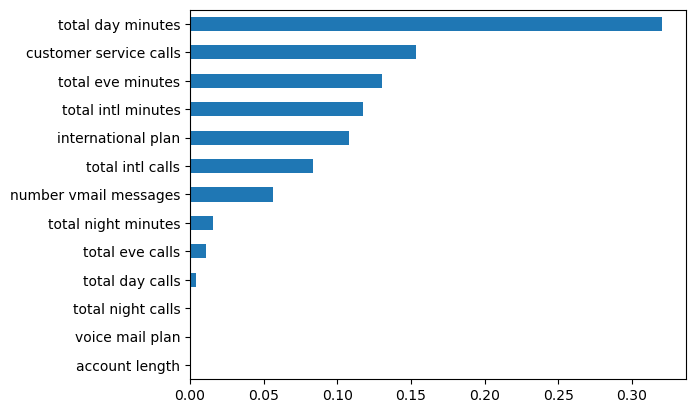

In [130]:
pd.Series(dt_model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')

# 6. DEPLOYMENT AND BUSINESS RECOMMENDATIONS

## 6.1 Business Recommendations

Based on the findings from the analysis and predictive modeling process, the following recommendations are proposed:

1. Improve Customer Service Quality  
Customers with higher numbers of customer service calls were more likely to churn. Improving customer support efficiency, reducing complaint resolution time, and enhancing customer experience may help reduce churn rates.

2. Monitor Customers with International Plans  
Customers subscribed to international plans demonstrated a higher tendency to churn. The company should review pricing structures, service quality, and customer satisfaction levels associated with these plans.

3. Develop Targeted Retention Campaigns  
The predictive model can be used to identify customers at high risk of churning, allowing the company to implement proactive retention strategies such as personalized offers and loyalty incentives.

4. Strengthen Customer Engagement Programs  
Providing additional value-added services and maintaining regular customer engagement may improve customer loyalty and long-term retention.

5. Continuously Monitor Customer Behavior  
Customer usage patterns and service interactions should be continuously monitored to detect early warning signs of dissatisfaction and potential churn behavior.

## 6.2 Deployment

The selected Decision Tree model can be integrated into the telecommunications company's operational systems to support customer churn prediction in real-world scenarios. Customer information can be continuously analyzed to identify customers at high risk of leaving the company.

The deployed model could support the organization by:

- Generating churn risk predictions for customers
- Supporting targeted marketing and retention campaigns
- Assisting customer support teams in identifying dissatisfied customers
- Improving business decision-making through predictive analytics

To maintain effectiveness, the model should be periodically retrained using updated customer data to adapt to changing customer behavior patterns and market conditions.

# 7. CONCLUSION

This project successfully applied machine learning techniques to predict customer churn within a telecommunications company using the CRISP-DM framework. Through data understanding, preparation, exploratory analysis, modeling, and evaluation, important factors influencing customer churn were identified.

The analysis revealed that customer service calls, international plan subscriptions, and customer usage behavior were significant indicators of churn. Multiple machine learning models were evaluated, with the Decision Tree Classifier demonstrating the strongest overall performance and the best balance between accuracy and churn detection capability.

The findings from this project highlight the value of predictive analytics in supporting customer retention strategies and improving business decision-making within the telecommunications industry.